In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
base_table = pd.read_csv("base_table.csv")

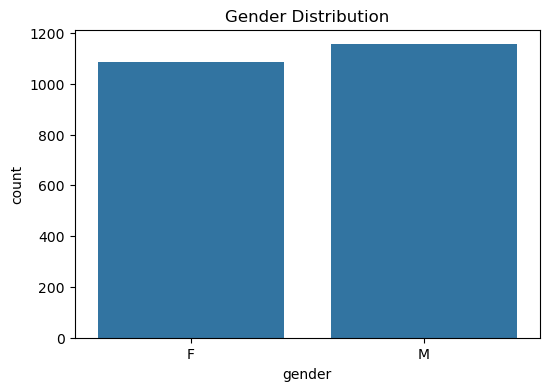

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=base_table, x='gender')
plt.title("Gender Distribution")
plt.show()

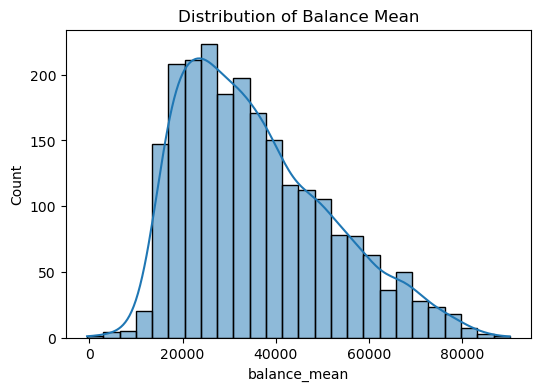

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(base_table ['balance_mean'], kde=True)
plt.title("Distribution of Balance Mean")
plt.show()

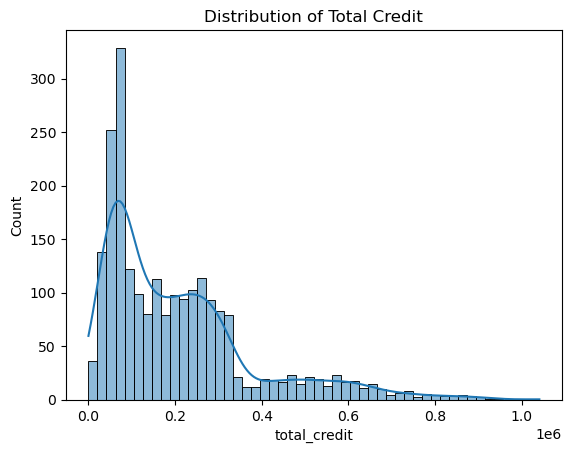

In [3]:
sns.histplot(base_table['total_credit'], bins=50, kde=True)
plt.title('Distribution of Total Credit')
plt.show()

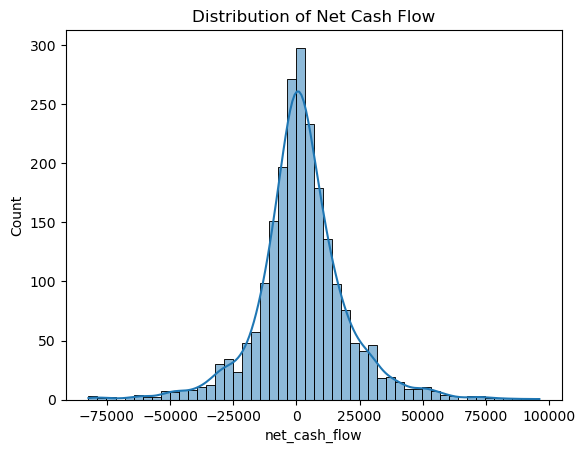

In [4]:
# Distribution of net cash flow
sns.histplot(base_table['net_cash_flow'], bins=50, kde=True)
plt.title('Distribution of Net Cash Flow')
plt.show()

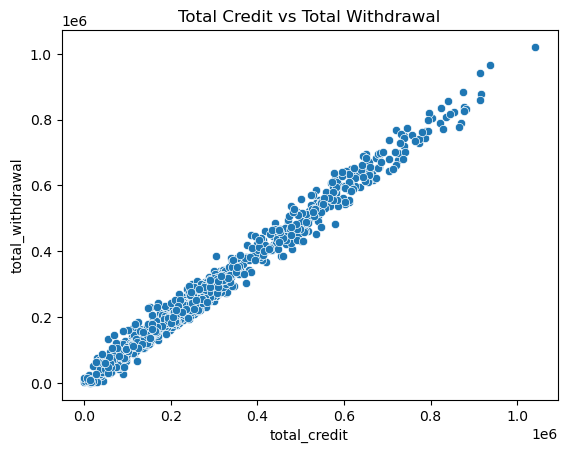

In [5]:
# Relationship between total_credit and total_withdrawal
sns.scatterplot(x='total_credit', y='total_withdrawal', data=base_table)
plt.title('Total Credit vs Total Withdrawal')
plt.show()

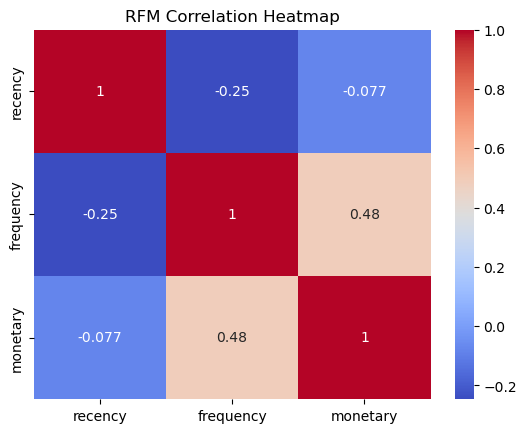

In [6]:
#RFM behavior heatmap
rfm_features = ['recency', 'frequency', 'monetary']
sns.heatmap(base_table[rfm_features].corr(), annot=True, cmap='coolwarm')
plt.title('RFM Correlation Heatmap')
plt.show()

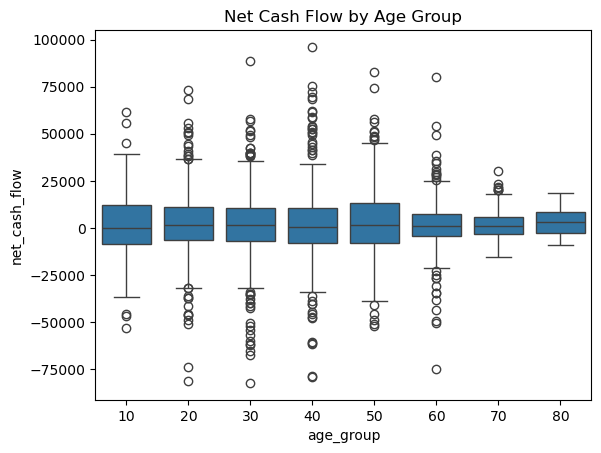

In [7]:
#Age group vs net cash flow
sns.boxplot(x='age_group', y='net_cash_flow', data=base_table)
plt.title('Net Cash Flow by Age Group')
plt.show()

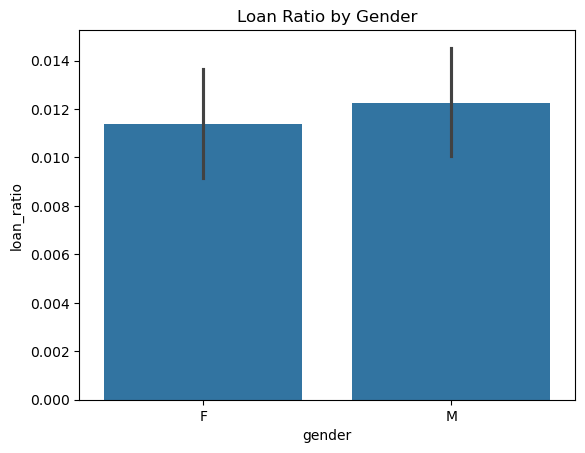

In [8]:
#Gender vs loan ratio
sns.barplot(x='gender', y='loan_ratio', data=base_table)
plt.title('Loan Ratio by Gender')
plt.show()

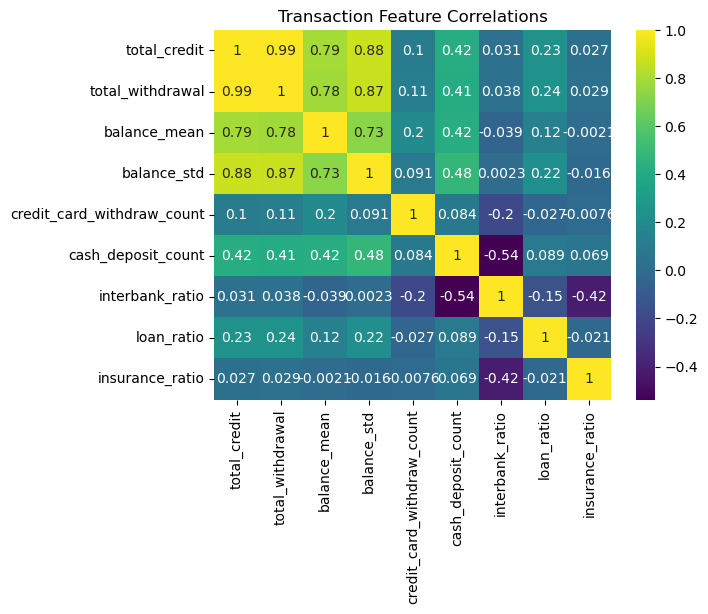

In [9]:
#Correlation matrix for transaction features
transaction_features = [
    'total_credit', 'total_withdrawal', 'balance_mean', 'balance_std',
    'credit_card_withdraw_count', 'cash_deposit_count', 'interbank_ratio',
    'loan_ratio', 'insurance_ratio'
]
sns.heatmap(base_table[transaction_features].corr(), annot=True, cmap='viridis')
plt.title('Transaction Feature Correlations')
plt.show()

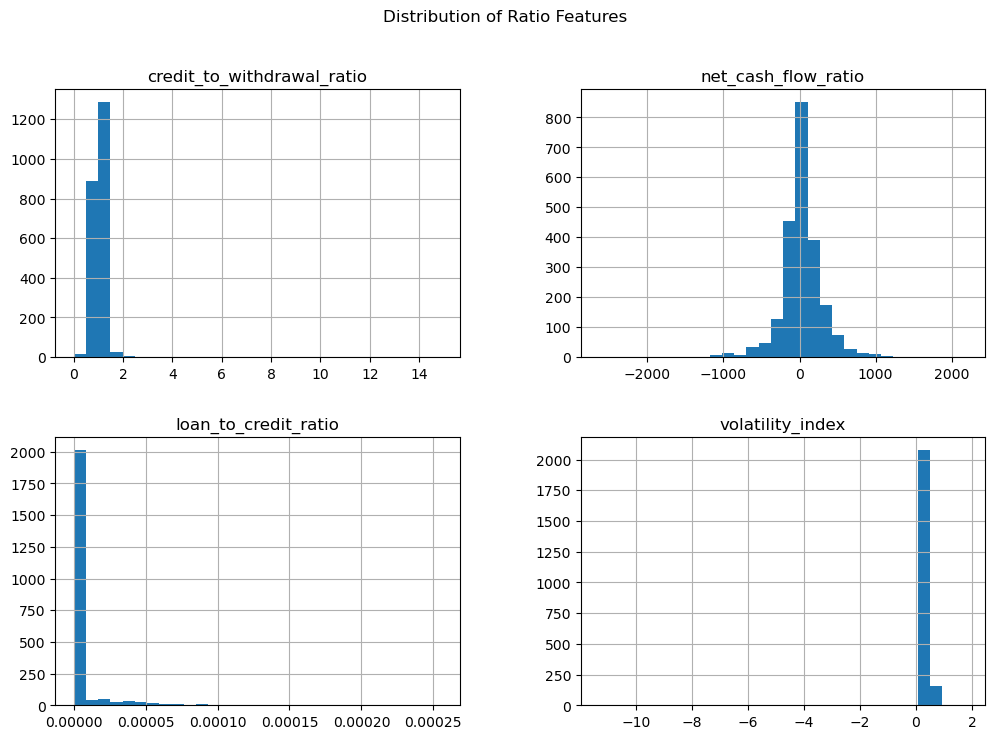

In [10]:
#Histogram of ratio features
ratio_features = ['credit_to_withdrawal_ratio', 'net_cash_flow_ratio', 'loan_to_credit_ratio', 'volatility_index']
base_table[ratio_features].hist(bins=30, figsize=(12,8))
plt.suptitle('Distribution of Ratio Features')
plt.show()

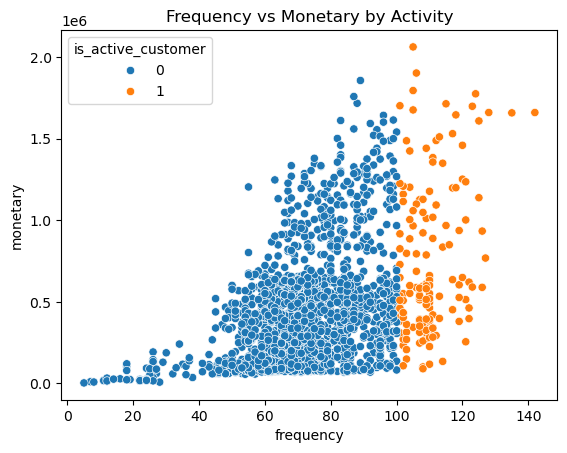

In [11]:
#Customer activity segmentation
sns.scatterplot(x='frequency', y='monetary', hue='is_active_customer', data=base_table)
plt.title('Frequency vs Monetary by Activity')
plt.show()

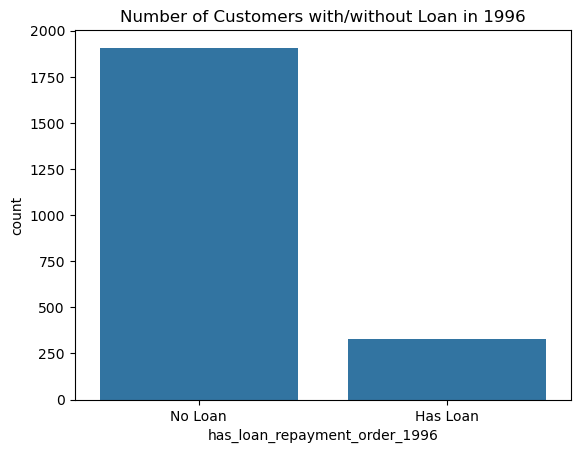

In [12]:
#Count of customers with and without loans
sns.countplot(x='has_loan_repayment_order_1996', data=base_table)
plt.xticks([0,1], ['No Loan', 'Has Loan'])
plt.title('Number of Customers with/without Loan in 1996')
plt.show()

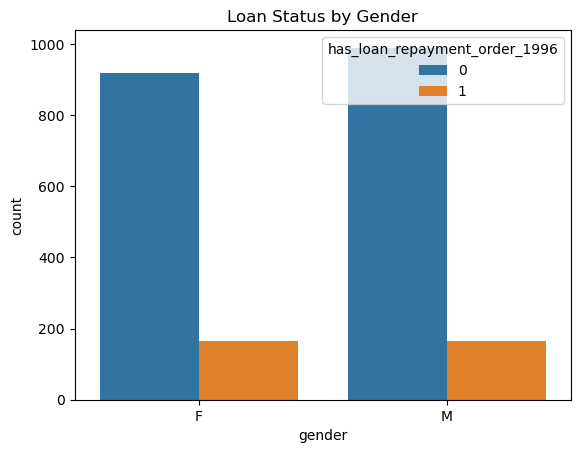

In [13]:
#Loan vs gender
sns.countplot(x='gender', hue='has_loan_repayment_order_1996', data=base_table)
plt.title('Loan Status by Gender')
plt.show()

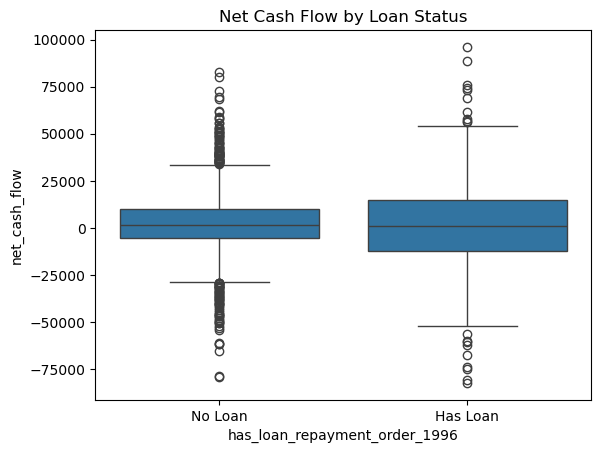

In [14]:
#Loan vs net cash flow
sns.boxplot(x='has_loan_repayment_order_1996', y='net_cash_flow', data=base_table)
plt.xticks([0,1], ['No Loan', 'Has Loan'])
plt.title('Net Cash Flow by Loan Status')
plt.show()

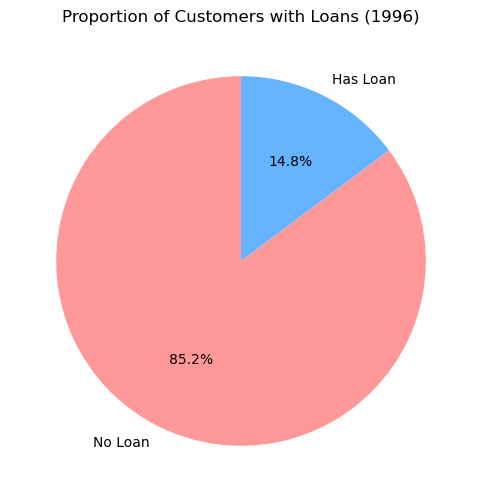

In [15]:
#Proportion of customers with/without loans

loan_counts = base_table['has_loan_repayment_order_1996'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(loan_counts, labels=['No Loan', 'Has Loan'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Proportion of Customers with Loans (1996)')
plt.show()

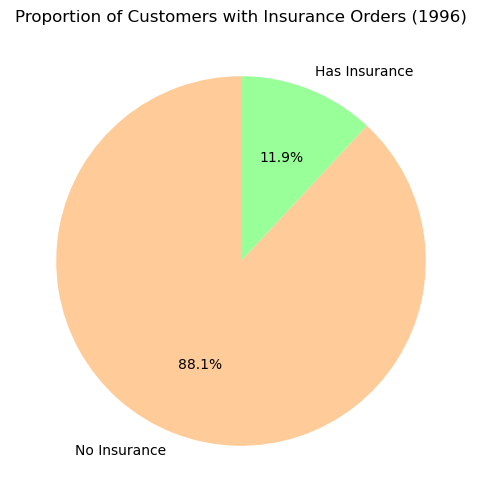

In [16]:
#Proportion of customers with/without insurance orders
insurance_counts = base_table['has_insurance_order_1996'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(insurance_counts, labels=['No Insurance', 'Has Insurance'], autopct='%1.1f%%', startangle=90, colors=['#ffcc99','#99ff99'])
plt.title('Proportion of Customers with Insurance Orders (1996)')
plt.show()

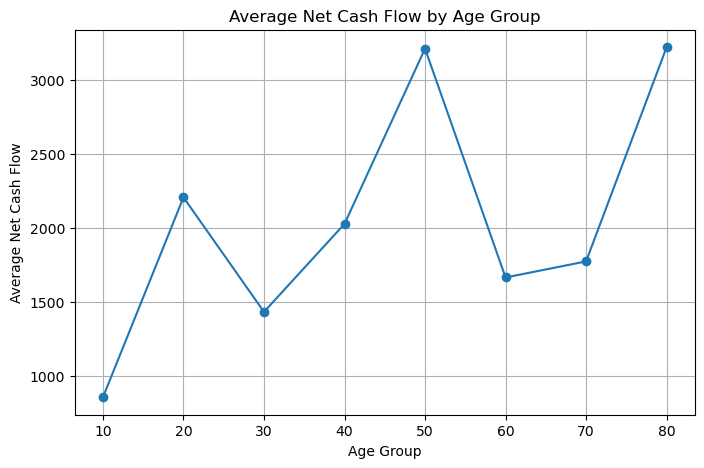

In [17]:
#Average net cash flow by age group
avg_net_cash_by_age = base_table.groupby('age_group')['net_cash_flow'].mean()
plt.figure(figsize=(8,5))
plt.plot(avg_net_cash_by_age.index, avg_net_cash_by_age.values, marker='o')
plt.title('Average Net Cash Flow by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Net Cash Flow')
plt.grid(True)
plt.show()

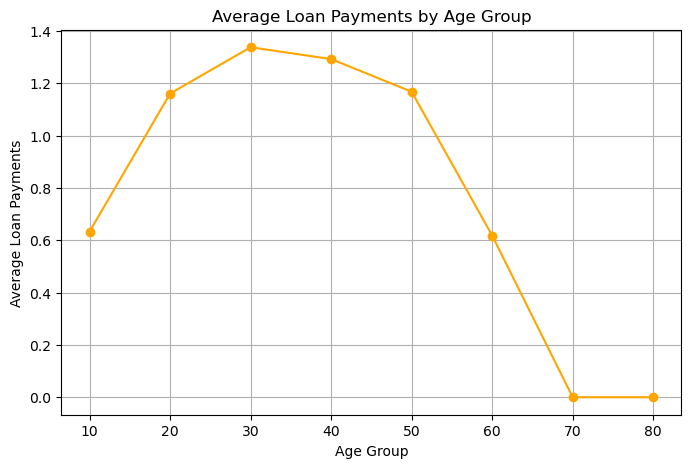

In [18]:
#Average loan payments by age group
avg_loan_by_age = base_table.groupby('age_group')['loan_payment_count'].mean()
plt.figure(figsize=(8,5))
plt.plot(avg_loan_by_age.index, avg_loan_by_age.values, marker='o', color='orange')
plt.title('Average Loan Payments by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Loan Payments')
plt.grid(True)
plt.show()

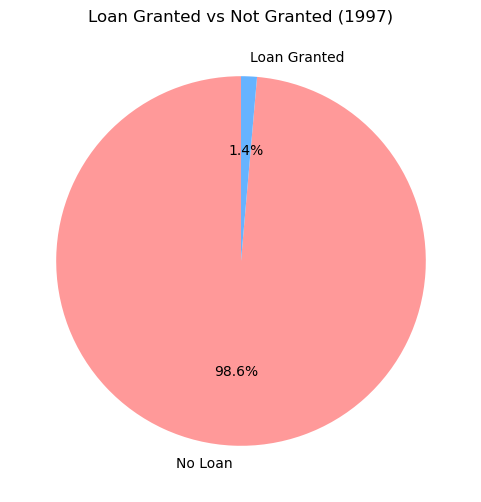

In [19]:
#Pie chart: Loan granted vs not granted
loan_counts = base_table['loan_1997'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(loan_counts, labels=['No Loan', 'Loan Granted'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Loan Granted vs Not Granted (1997)')
plt.show()

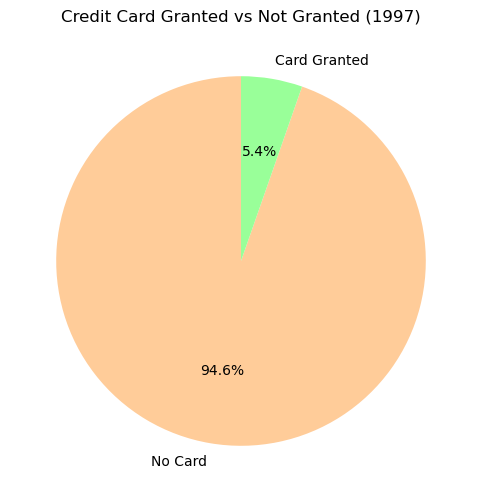

In [20]:
#Pie chart: Credit card granted vs not granted
card_counts = base_table['card_1997'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(card_counts, labels=['No Card', 'Card Granted'], autopct='%1.1f%%', startangle=90, colors=['#ffcc99','#99ff99'])
plt.title('Credit Card Granted vs Not Granted (1997)')
plt.show()

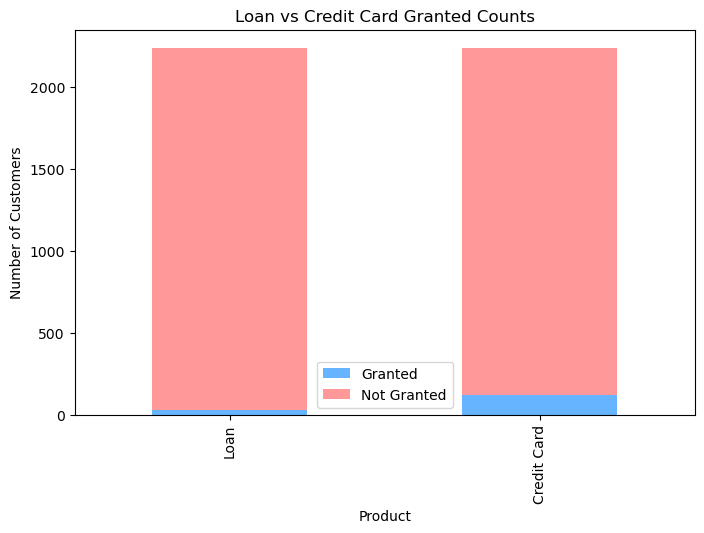

In [21]:
#Bar chart: Loan vs Credit Card counts
counts = pd.DataFrame({
    'Product': ['Loan', 'Credit Card'],
    'Granted': [base_table['loan_1997'].sum(), base_table['card_1997'].sum()],
    'Not Granted': [len(base_table)-base_table['loan_1997'].sum(), len(base_table)-base_table['card_1997'].sum()]
})

counts.set_index('Product')[['Granted','Not Granted']].plot(kind='bar', stacked=True, figsize=(8,5), color=['#66b3ff','#ff9999'])
plt.ylabel('Number of Customers')
plt.title('Loan vs Credit Card Granted Counts')
plt.show()

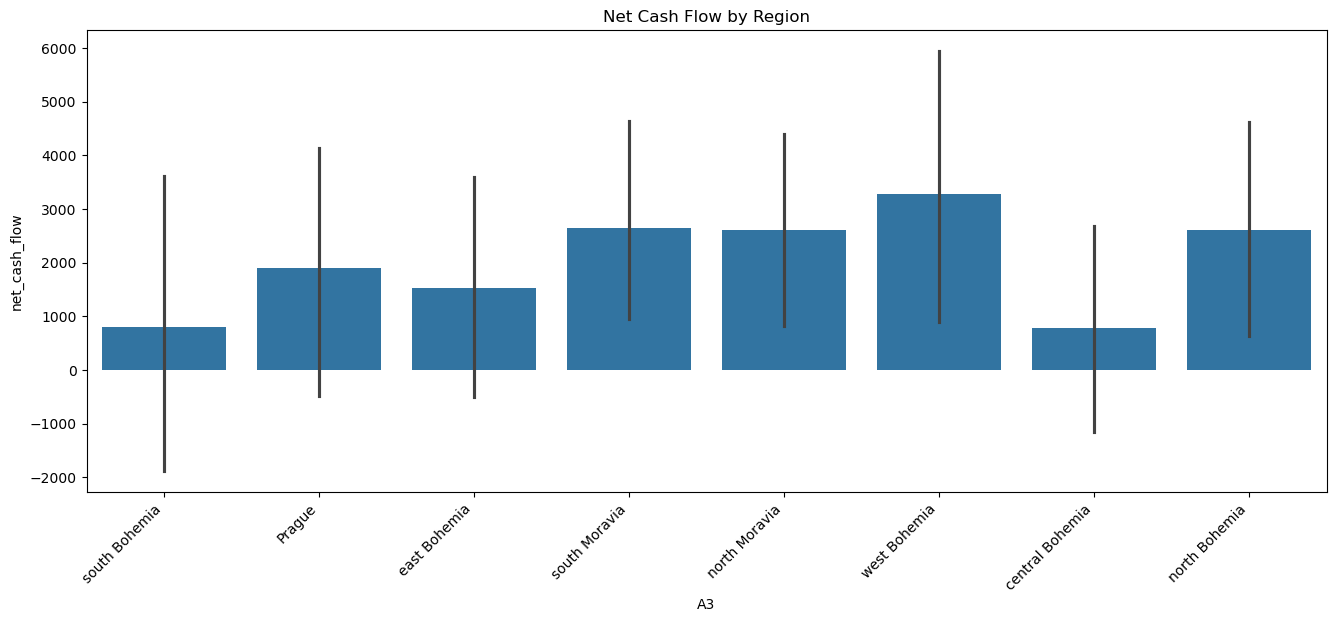

In [22]:
# --- Net cash flow by region ---
plt.figure(figsize=(16,6))  # increased width
sns.barplot(x='A3', y='net_cash_flow', data=base_table)
plt.title('Net Cash Flow by Region')
plt.xticks(rotation=45, ha='right')  # rotate labels for readability
plt.show()

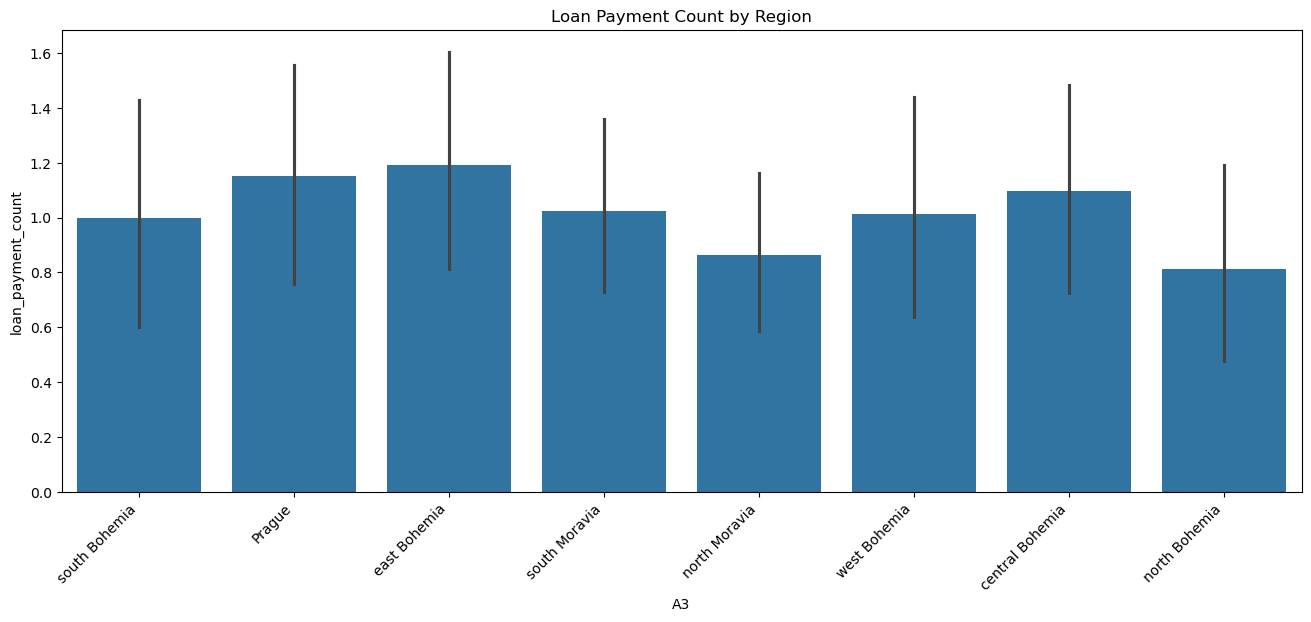

In [23]:
# --- Loan payments by region ---
plt.figure(figsize=(16,6))  # increased width
sns.barplot(x='A3', y='loan_payment_count', data=base_table)
plt.title('Loan Payment Count by Region')
plt.xticks(rotation=45, ha='right')  # rotate labels for readability
plt.show()